In [1]:
print("BUSI")

BUSI


In [2]:

import numpy as np 
import pandas as pd 

import os

dataset_path = "Dataset_BUSI_with_GT"

for dirname, _, filenames in os.walk(dataset_path):
    for filename in filenames:
        print(os.path.join(dirname, filename))


Dataset_BUSI_with_GT\benign\benign (1).png
Dataset_BUSI_with_GT\benign\benign (1)_mask.png
Dataset_BUSI_with_GT\benign\benign (10).png
Dataset_BUSI_with_GT\benign\benign (10)_mask.png
Dataset_BUSI_with_GT\benign\benign (100).png
Dataset_BUSI_with_GT\benign\benign (100)_mask.png
Dataset_BUSI_with_GT\benign\benign (100)_mask_1.png
Dataset_BUSI_with_GT\benign\benign (101).png
Dataset_BUSI_with_GT\benign\benign (101)_mask.png
Dataset_BUSI_with_GT\benign\benign (102).png
Dataset_BUSI_with_GT\benign\benign (102)_mask.png
Dataset_BUSI_with_GT\benign\benign (103).png
Dataset_BUSI_with_GT\benign\benign (103)_mask.png
Dataset_BUSI_with_GT\benign\benign (104).png
Dataset_BUSI_with_GT\benign\benign (104)_mask.png
Dataset_BUSI_with_GT\benign\benign (105).png
Dataset_BUSI_with_GT\benign\benign (105)_mask.png
Dataset_BUSI_with_GT\benign\benign (106).png
Dataset_BUSI_with_GT\benign\benign (106)_mask.png
Dataset_BUSI_with_GT\benign\benign (107).png
Dataset_BUSI_with_GT\benign\benign (107)_mask.png
Data

In [3]:
import torch
import torch.nn as nn
import pennylane as qml
import numpy as np

from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cpu


In [6]:
train_transforms = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

test_transforms = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [8]:
from torchvision.datasets import ImageFolder

class CleanImageFolder(ImageFolder):
    def __init__(self, root, transform=None):
        super().__init__(root, transform)
        self.samples = [
            (p,y) for p,y in self.samples if "_mask" not in p
        ]

dataset_path = "Dataset_BUSI_with_GT"

dataset = CleanImageFolder(dataset_path, train_transforms)

print(dataset.classes)


['benign', 'malignant', 'normal']


In [9]:
train_size = int(0.7 * len(dataset))
val_size = int(0.15 * len(dataset))
test_size = len(dataset) - train_size - val_size

train_ds, val_ds, test_ds = torch.utils.data.random_split(
    dataset, [train_size, val_size, test_size]
)

val_ds.dataset.transform = test_transforms
test_ds.dataset.transform = test_transforms

In [10]:
train_loader = DataLoader(train_ds, batch_size=16, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=16, shuffle=False)

In [11]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

train_labels = [label for _, label in train_ds]

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_labels),
    y=train_labels
)

class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)

print("Class Weights:", class_weights)

Class Weights: tensor([0.5948, 1.2552, 1.9158])


In [12]:
class ClassicalCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 16, 3, stride=2),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, 3, stride=2),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1,1))
        )
        self.fc = nn.Linear(32, 4)

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        return self.fc(x)


In [13]:
n_qubits = 4
dev = qml.device("default.qubit", wires=n_qubits)

@qml.qnode(dev, interface="torch")
def quantum_circuit(inputs, weights):
    qml.AngleEmbedding(inputs, wires=range(n_qubits))
    qml.StronglyEntanglingLayers(weights, wires=range(n_qubits))
    return [qml.expval(qml.PauliZ(i)) for i in range(3)]

In [14]:
weight_shapes = {"weights": (4, n_qubits, 3)}
quantum_layer = qml.qnn.TorchLayer(quantum_circuit, weight_shapes)

In [15]:
class HybridQCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.cnn = ClassicalCNN()
        self.quantum = quantum_layer

    def forward(self, x):
        x = self.cnn(x)
        x = self.quantum(x)
        return x

In [16]:
model = HybridQCNN().to(device)

In [17]:
criterion = nn.CrossEntropyLoss(weight=class_weights)

optimizer = torch.optim.Adam(model.parameters(), lr=0.0005)

In [18]:
def train(model, loader, epochs=40):
    for epoch in range(epochs):
        model.train()
        total_loss = 0
        
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            total_loss += loss.item()
        
        print(f"Epoch {epoch+1}/{epochs} - Loss: {total_loss/len(loader):.4f}")

In [19]:
train(model, train_loader, epochs=40)

Epoch 1/40 - Loss: 1.1408
Epoch 2/40 - Loss: 1.1043
Epoch 3/40 - Loss: 1.0854
Epoch 4/40 - Loss: 1.0645
Epoch 5/40 - Loss: 1.0559
Epoch 6/40 - Loss: 1.0483
Epoch 7/40 - Loss: 1.0427
Epoch 8/40 - Loss: 1.0412
Epoch 9/40 - Loss: 1.0386
Epoch 10/40 - Loss: 1.0360
Epoch 11/40 - Loss: 1.0147
Epoch 12/40 - Loss: 1.0210
Epoch 13/40 - Loss: 1.0085
Epoch 14/40 - Loss: 1.0135
Epoch 15/40 - Loss: 1.0126
Epoch 16/40 - Loss: 1.0067
Epoch 17/40 - Loss: 1.0007
Epoch 18/40 - Loss: 0.9922
Epoch 19/40 - Loss: 1.0087
Epoch 20/40 - Loss: 1.0126
Epoch 21/40 - Loss: 1.0022
Epoch 22/40 - Loss: 0.9837
Epoch 23/40 - Loss: 0.9786
Epoch 24/40 - Loss: 0.9785
Epoch 25/40 - Loss: 0.9732
Epoch 26/40 - Loss: 0.9784
Epoch 27/40 - Loss: 0.9669
Epoch 28/40 - Loss: 0.9647
Epoch 29/40 - Loss: 0.9810
Epoch 30/40 - Loss: 0.9706
Epoch 31/40 - Loss: 0.9714
Epoch 32/40 - Loss: 0.9712
Epoch 33/40 - Loss: 0.9950
Epoch 34/40 - Loss: 0.9709
Epoch 35/40 - Loss: 0.9703
Epoch 36/40 - Loss: 0.9720
Epoch 37/40 - Loss: 0.9645
Epoch 38/4

In [20]:
def evaluate(model, loader):
    model.eval()
    y_true = []
    y_pred = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            outputs = model(images)
            preds = torch.argmax(outputs, 1)
            
            y_true.extend(labels.numpy())
            y_pred.extend(preds.cpu().numpy())

    print(classification_report(
        y_true, y_pred,
        target_names=dataset.classes
    ))

    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt="d",
                xticklabels=dataset.classes,
                yticklabels=dataset.classes,
                cmap="Blues")
    plt.show()

    unique, counts = np.unique(y_pred, return_counts=True)
    print("Prediction distribution:", dict(zip(unique, counts)))

              precision    recall  f1-score   support

      benign       0.74      0.55      0.63        64
   malignant       0.76      0.76      0.76        34
      normal       0.28      0.53      0.36        19

    accuracy                           0.61       117
   macro avg       0.60      0.61      0.59       117
weighted avg       0.67      0.61      0.63       117



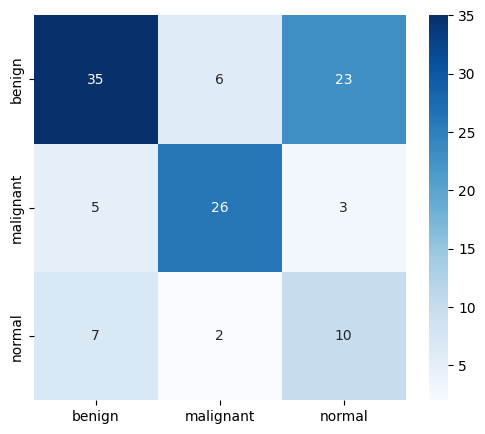

Prediction distribution: {np.int64(0): np.int64(47), np.int64(1): np.int64(34), np.int64(2): np.int64(36)}


In [21]:
evaluate(model, test_loader)